# DDPG on Pendulum: the first continuous-action rung

Every policy elsewhere in this repo outputs a `Categorical`. DDPG is the first that outputs a
number: a deterministic actor maps the 3-dim Pendulum state to a torque in [-2, 2], and a critic
Q(s, a) supplies the gradient that tells the actor which way to move it. Most of the machinery is
DQN's — replay buffer, target networks, Polyak averaging — so the genuinely new parts are small:
a `tanh`-bounded actor, a critic that takes the action as input, and exploration by adding noise
rather than sampling.

Compared over **10 seeds**, which Pendulum's minutes-per-run makes affordable again after Pong
forced n = 1.

**Result, up front:** all 10 seeds converge to a greedy return of -110 to -117 (mean -113.9), and
there is no collapse — the change between the last two windows of training is -0.7 +- 1.0.
The critic never breaks its hard ceiling of Q <= 0. The more instructive results are about
measurement: an apparent 52-point "collapse" in an earlier version turned out to be selection bias
in the metric, and fixing the evaluation seeds shrank the confidence interval nineteenfold.

In [34]:
import cv2
import random
import torch
import imageio
import numpy as np
import pandas as pd
import gymnasium as gym
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import deque, namedtuple
from torch.utils.tensorboard import SummaryWriter
from IPython.display import Image

In [35]:
env = gym.make("Pendulum-v1")

In [36]:
env.action_space

Box(-2.0, 2.0, (1,), float32)

In [37]:
env.observation_space

Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)

## Components

Replay buffer, actor, critic, exploration noise and the soft target update. Two architectural
details:

- **The actor ends in `2 * tanh`.** Pendulum's action range is [-2, 2]; a bare linear output
  either saturates the environment's clip or has to learn the scale.
- **The critic concatenates the action at its second layer**, after a 256-unit state encoder,
  following the original DDPG paper. An earlier version used a 32-unit state encoder there — a
  tight bottleneck that the paper does not have (it used 400).

In [38]:
class Replay_memory:
    '''
        The memory for storing and sampling experiences
    '''
    def __init__(self, memory_size, seed):
        random.seed(seed)
        self.memory_size = memory_size
        self.memory = deque(maxlen = memory_size)
        self.transition = namedtuple(typename='Transition', field_names= ['state', 'action', 'reward',\
                                                                          'next_state', 'done'])
    def add(self, state, action, reward, next_state, done):
        '''
            adding the experience to the memory
        '''
        self.memory.append(self.transition(state, action, reward, next_state, done))
        
    def sample(self, size, device):
        '''
            samples the experiences from the memory
        '''
        samples = random.sample(self.memory, size)
        states = torch.from_numpy(np.array([e.state for e in samples])).float().to(device)
        actions = torch.from_numpy(np.array([e.action for e in samples])).to(device)
        rewards = torch.from_numpy(np.array([e.reward for e in samples])).float().to(device).unsqueeze(1)
        next_states = torch.from_numpy(np.array([e.next_state for e in samples])).float().to(device)
        dones = torch.from_numpy(np.array([e.done for e in samples])).to(device).unsqueeze(1)
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.memory)

In [39]:
class Actor(nn.Module):

    def __init__(self,state_size, action_size, seed =0):
        super().__init__()
        torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(state_size, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_size),
            nn.Tanh()
        )

    def forward(self, state):
        action = 2*self.net(state)
        return action

In [40]:
class Critic(nn.Module):

    def __init__(self,state_size, action_size, seed =0):
        super().__init__()
        torch.manual_seed(seed)
        self.fc1 = nn.Linear(state_size, 256)
        self.fc2 = nn.Linear(256 + action_size, 256)
        self.fc3 = nn.Linear(256, 256)
        self.fc4 = nn.Linear(256, 1)

    def forward(self, state, action):
        out = F.relu(self.fc1(state))
        out = F.relu(self.fc2(torch.cat([out, action], dim=1)))
        out = F.relu(self.fc3(out))
        out = self.fc4(out)
        
        return out

### Exploration

A deterministic policy has no distribution to sample, so exploration is noise added to the
action. This uses Ornstein-Uhlenbeck noise as in the paper, and its timescale matters more than
its size: with `theta=0.15` the correlation time is `1/(theta*dt)` steps. At the original
`dt=0.01` that is 667 steps against a 200-step episode — a slowly drifting constant offset
rather than exploration, measured at -0.57..+0.09 across a whole episode. `dt=0.05` brings it
to 133 steps, and `reset()` is called every episode so the offset does not carry over. Plain
Gaussian noise is a reasonable alternative; later work found it performs as well.

In [41]:
class OUActionNoise:
    def __init__(self, mean, std_deviation, seed,theta=0.15, dt=.05, x_initial=None):
        np.random.seed(seed)
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        #correlated to previous noise
        x = (
            self.x_prev
            + self.theta * (self.mean - self.x_prev) * self.dt
            + self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape)
        )
        # Store x into x_prev
        # Makes next noise dependent on current one
        self.x_prev = x
        return x.astype(np.float32)

    def reset(self):
        if self.x_initial is not None:
            self.x_prev = self.x_initial
        else:
            self.x_prev = np.zeros_like(self.mean)

In [42]:
def update_target(critic_local, critic_target, actor_local, actor_target, tau):
    for local_param, target_param in zip(critic_local.parameters(), critic_target.parameters()):
        target_param.data.copy_(tau*local_param.data + (1-tau)*target_param.data)
    for local_param, target_param in zip(actor_local.parameters(), actor_target.parameters()):
        target_param.data.copy_(tau*local_param.data + (1-tau)*target_param.data)

## Configuration

| | |
|---|---|
| episodes x steps | 200 x 200 = 40k environment steps per seed |
| gamma / tau | 0.99 / 1e-3 (Polyak, every step) |
| learning rate | actor 3e-4, critic 5e-4 |
| replay | 50k transitions, batch 64, updates start at 500 |
| noise | OU, sigma 0.2, theta 0.15, dt 0.05 |

Pendulum's reward is `-(theta^2 + 0.1*theta_dot^2 + 0.001*a^2)`, which lies in [-16.27, 0], and
episodes are exactly 200 steps with no termination. With gamma = 0.99 that bounds the critic to
**Q in [-1409, 0]** — and the upper end is the useful one: any positive Q is provably wrong,
with no arithmetic needed.

In [43]:
n_episodes =200
GAMMA = 0.99
TAU = 1e-3              # for soft update of target parameters
LR_ACTOR = .0003         # learning rate of the actor 
LR_CRITIC = .0005        # learning rate of the critic
memory_size = 50000
batch_size = 64
noise_std = 0.2
noise_mean = np.zeros(1).astype(np.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Evaluation

Greedy (no noise), on a separate environment instance, from **10 fixed start states**
(`reset(seed=10_000 + i)`), every 10 episodes. All 10 per-episode returns are kept rather than
their mean, giving a `(seeds, checkpoints, eval episodes)` array.

Fixing the start states is what makes checkpoints comparable. Pendulum resets the angle uniformly
in [-pi, pi], so a near-upright start and a full swing-up differ by hundreds of points for the
*same* policy. With random starts each checkpoint is a fresh draw; with fixed starts, episode i is
the same situation at every checkpoint and comparisons are paired.

In [44]:
def evaluate(actor, device, n_eps=10, return_scores = False):
    env = gym.make("Pendulum-v1")
    all_returns = []
    for i in range(n_eps):
        state, _ = env.reset(seed=10_000 + i)   # same starts at every checkpoint
        ep_return = 0.0
        while True:
            state_t = torch.tensor(state).unsqueeze(0).to(device)
            action = actor(state_t)
            action = action.cpu().detach().squeeze().numpy()
            action = np.clip(action, env.action_space.low, env.action_space.high)
            state, reward, done, truncated, info = env.step(action)
            ep_return +=reward
            if done or truncated:
                break
        all_returns.append(ep_return)

    env.close()
    if return_scores:
        return all_returns
    return np.mean(all_returns)
    


## Training loop

Each step: act with noise, store, sample a batch, update the critic toward a target computed by
the target networks, update the actor through the critic, then soft-update both targets. Four
details here each broke a working version of this notebook, silently:

- **The actor loss must go through the actor.** `-critic(states, actor(states))`, not
  `-critic(states, actions)` with the buffer's actions. With buffer actions there is no path from
  the actor's parameters to the loss, so `actor.grad` stays `None` and `optimizer_actor.step()`
  is a no-op — but nothing errors, because the loss still requires grad through the critic. The
  actor sat at its random initialisation for a whole run (average return -1537).
- **The actor trains on the replay batch, not the current state.** An earlier version computed
  the actor loss on the single state just taken from the environment — a batch of one, from
  consecutive correlated states, while the critic got 64.
- **Store `done`, never `done or truncated`.** Pendulum never terminates: over 2000 steps it
  reports `terminated=0, truncated=10`. Storing the time limit as terminal made every episode
  boundary a zero-value target. Same rule as `done = not interrupted` in the Unity notebooks and
  `terminated` vs `terminated | truncated` in the Pong one.
- **The actor's backward pass fills the critic's `.grad` too.** The critic is in the graph, so
  its gradient buffers get the actor's gradient. They are not applied — only the actor's optimizer
  steps — but they are still there, and `optimizer_critic.zero_grad()` must run before the
  critic's own backward.

Warm-up episodes with no updates log `NaN`, so every per-episode array lines up with the scores.

In [45]:
def run(env, seed):
    env.reset(seed=seed); env.action_space.seed(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    noise = OUActionNoise(mean=noise_mean, std_deviation=noise_std, seed= seed)
    actor_local = Actor(env.observation_space.shape[0], env.action_space.shape[0],seed).to(device)
    critic_local = Critic(env.observation_space.shape[0], env.action_space.shape[0], seed).to(device)

    actor_target = Actor(env.observation_space.shape[0], env.action_space.shape[0], seed).to(device)
    critic_target = Critic(env.observation_space.shape[0], env.action_space.shape[0], seed).to(device)
    actor_target.load_state_dict(actor_local.state_dict())
    critic_target.load_state_dict(critic_local.state_dict())

    replay_memory = Replay_memory(memory_size, seed)
    optimizer_actor = torch.optim.Adam(actor_local.parameters(), LR_ACTOR)
    optimizer_critic = torch.optim.Adam(critic_local.parameters(), LR_CRITIC)

    all_rewards = []
    q_values = []
    actor_losses = []
    critic_losses = []
    recent_rewards = deque(maxlen=30)
    greedy_curve = []


    for n in range(n_episodes):    
        state, _ = env.reset()
        ep_reward = 0
        ep_q_values = []
        ep_actor_loss = []
        ep_critic_loss = []
        while True:
            state_t = torch.tensor(state).unsqueeze(0).to(device)
            action = actor_local(state_t)
            action = action.cpu().detach().squeeze().numpy()
            action = np.clip(action + noise(), env.action_space.low, env.action_space.high)
            next_state, reward, done, truncated, info = env.step(action)
            replay_memory.add(state, action, reward, next_state, done)
            if len(replay_memory) >= 500:
                states, actions, rewards, next_states, dones = replay_memory.sample(batch_size, device)
                q_curr = critic_local(states, actions)
                with torch.no_grad():
                    next_actions = actor_target(next_states)
                    q_next = critic_target(next_states, next_actions)
                    target = rewards + GAMMA* q_next*(1-dones*1.0)
            
                loss_critic = F.mse_loss(q_curr, target)
                optimizer_critic.zero_grad()
                loss_critic.backward()
                optimizer_critic.step()
                ep_q_values.append(q_curr.mean().item())
                ep_critic_loss.append(loss_critic.item())

                actions_pred = actor_local(states) 
                actor_loss = -critic_local(states, actions_pred).mean()
                optimizer_actor.zero_grad()
                actor_loss.backward()
                optimizer_actor.step() 
                ep_actor_loss.append(actor_loss.item())


            state = next_state
            ep_reward += reward
            update_target(critic_local, critic_target, actor_local, actor_target, TAU)
            if done or truncated:
                noise.reset() 
                recent_rewards.append(ep_reward)
                all_rewards.append(ep_reward)
                # NaN for warm-up episodes with no updates, so every array lines up with all_rewards
                q_values.append(np.mean(ep_q_values) if ep_q_values else np.nan)
                actor_losses.append(np.mean(ep_actor_loss) if ep_actor_loss else np.nan)
                critic_losses.append(np.mean(ep_critic_loss) if ep_critic_loss else np.nan)
                print('\rEpisode: {}, Reward: {}, Average Reward: {}'.format(n, ep_reward, np.mean(recent_rewards)), end="")
                break

        if (n+1)%10==0:
            eval_scores = evaluate(actor_local, device, return_scores=True)   # all 10 episodes, not the mean
            greedy_curve.append(eval_scores)
            print(f'\nEpisode {n} score for 10 runs: {np.mean(eval_scores):.2f}')

    # identical to greedy_curve[-1]: same actor, same fixed eval seeds, deterministic policy
    greedy_eval = evaluate(actor_local, device, return_scores=True)


    return all_rewards, q_values, actor_losses, critic_losses, greedy_eval, greedy_curve
            

## Ten seeds

In [46]:
seeds = list(range(10))
ddpg_rewards = []
ddpg_q_values = []
ddpg_actor_loss = []
ddpg_critic_loss = []
ddpg_greedy_eval = []
ddpg_greedy_curve = []
for seed in seeds:
    print(f"\nSeed: {seed}")
    all_rewards, ep_q_values, ep_actor_loss, ep_critic_loss, greedy_eval, greedy_curve \
        = run(env, seed)
    ddpg_rewards.append(all_rewards)
    ddpg_q_values.append(ep_q_values)
    ddpg_actor_loss.append(ep_actor_loss)
    ddpg_critic_loss.append(ep_critic_loss)
    ddpg_greedy_eval.append(greedy_eval)
    ddpg_greedy_curve.append(greedy_curve)

ddpg_results = {
    "scores": np.array(ddpg_rewards),
    "q_values": np.array(ddpg_q_values),
    "actor_loss": np.array(ddpg_actor_loss),
    "critic_loss": np.array(ddpg_critic_loss),
    "greedy_evals": np.array(ddpg_greedy_eval),
    "greedy_curve": np.array(ddpg_greedy_curve)
}


Seed: 0
Episode: 9, Reward: -1431.8716986374866, Average Reward: -1465.9844636139574
Episode 9 score for 10 runs: -1284.54
Episode: 19, Reward: -18.425754482490987, Average Reward: -1281.0674761816767
Episode 19 score for 10 runs: -1408.20
Episode: 29, Reward: -1166.1346207615497, Average Reward: -1284.3104505810478
Episode 29 score for 10 runs: -1137.99
Episode: 39, Reward: -1053.8370737733355, Average Reward: -1178.8380591244422
Episode 39 score for 10 runs: -715.22
Episode: 49, Reward: -3.1048608985497532, Average Reward: -1053.6037741801924
Episode 49 score for 10 runs: -249.63
Episode: 59, Reward: -137.61467017490617, Average Reward: -717.4639116528309
Episode 59 score for 10 runs: -189.72
Episode: 69, Reward: -12.56337365704917, Average Reward: -429.42110854978153
Episode 69 score for 10 runs: -132.72
Episode: 79, Reward: -136.96387578938783, Average Reward: -276.54489896960664
Episode 79 score for 10 runs: -115.83
Episode: 89, Reward: -262.5394070174693, Average Reward: -250.65

## Training curves

Training returns include exploration noise, so they sit below the greedy evaluation: around -153
at the end against -114 greedy. Mean Q per episode rises to about -24 during early training,
settles around -45 to -52, and its maximum across every seed and episode is -5.69 — never above
the Q <= 0 ceiling. No sign of the overestimation TD3 is designed to correct.

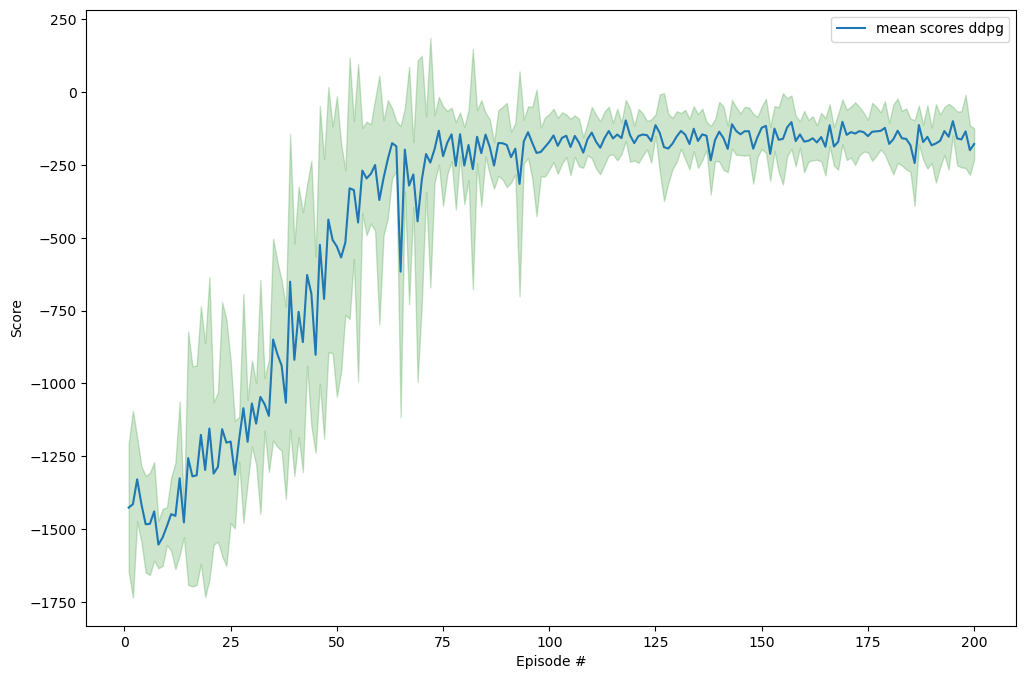

In [47]:
plt.figure(figsize=(12,8))
mean = np.nanmean(ddpg_results['scores'], axis =0)
std = np.nanstd(ddpg_results['scores'], axis =0)
x = np.arange(len(mean))+1
plt.plot(x,mean, label='mean scores ddpg')
plt.fill_between(x,mean-std, mean+std, alpha=0.2, color='green')
plt.legend()
plt.xlabel('Episode #')
plt.ylabel('Score')
plt.show()

/tmp/ipykernel_56302/3539139826.py:2: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(ddpg_results['q_values'], axis =0)
/home/neeraj/anaconda3/envs/gym/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


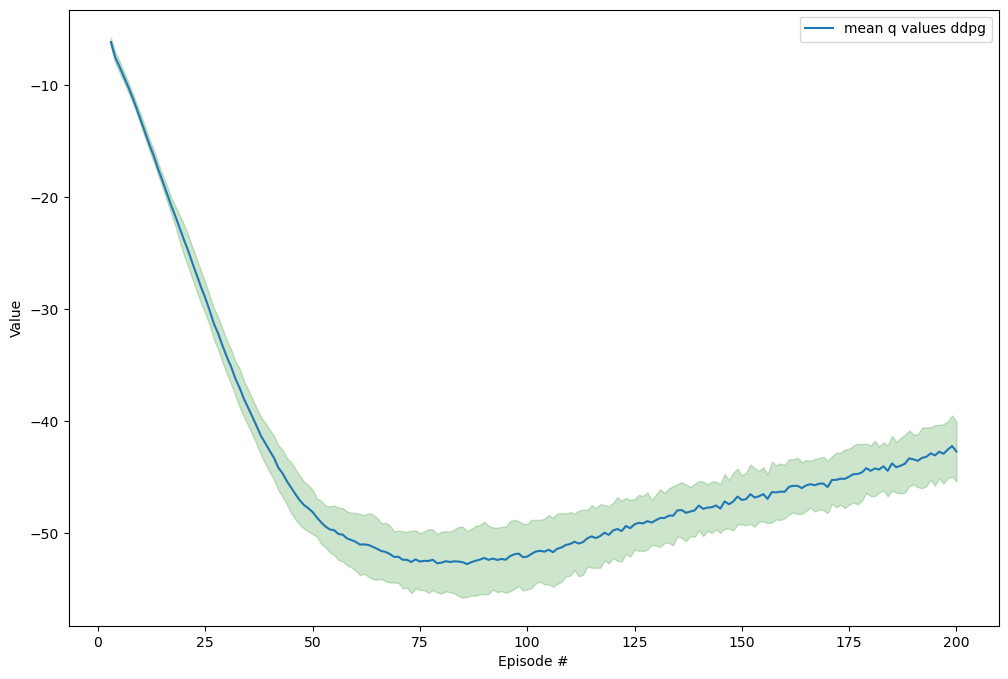

In [48]:
plt.figure(figsize=(12,8))
mean = np.nanmean(ddpg_results['q_values'], axis =0)
std = np.nanstd(ddpg_results['q_values'], axis =0)
x = np.arange(len(mean))+1
plt.plot(x,mean, label='mean q values ddpg')
plt.fill_between(x,mean-std, mean+std, alpha=0.2, color='green')
plt.legend()
plt.xlabel('Episode #')
plt.ylabel('Value')
plt.show()

/tmp/ipykernel_56302/1410476911.py:2: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(ddpg_results['actor_loss'], axis =0)


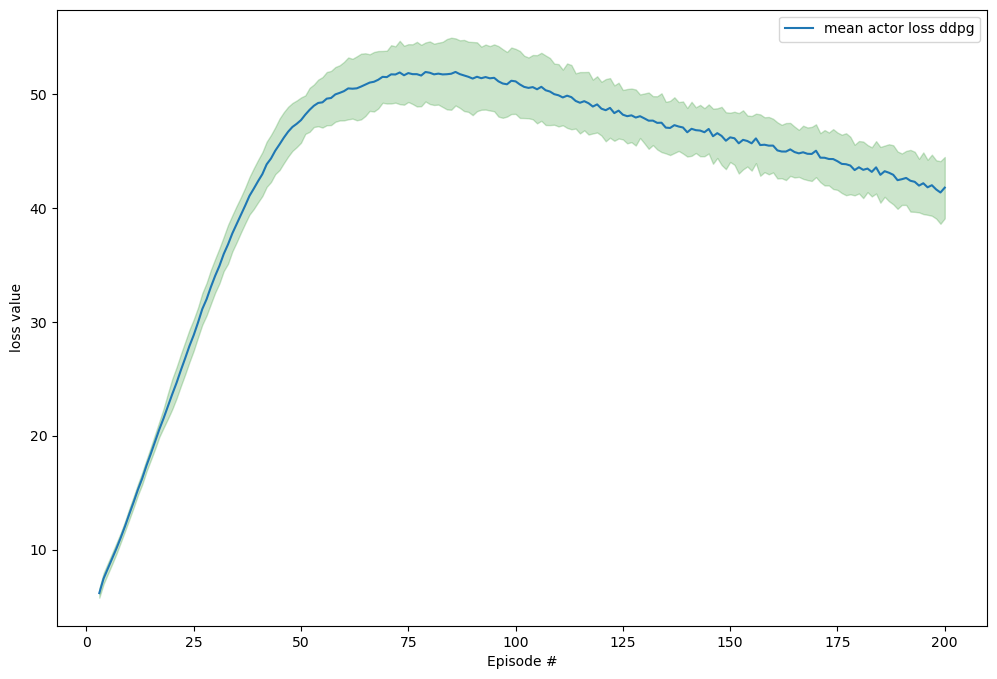

In [49]:
plt.figure(figsize=(12,8))
mean = np.nanmean(ddpg_results['actor_loss'], axis =0)
std = np.nanstd(ddpg_results['actor_loss'], axis =0)
x = np.arange(len(mean))+1
plt.plot(x,mean, label='mean actor loss ddpg')
plt.fill_between(x,mean-std, mean+std, alpha=0.2, color='green')
plt.legend()
plt.xlabel('Episode #')
plt.ylabel('loss value')
plt.show()

/tmp/ipykernel_56302/940254813.py:2: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(ddpg_results['critic_loss'], axis =0)


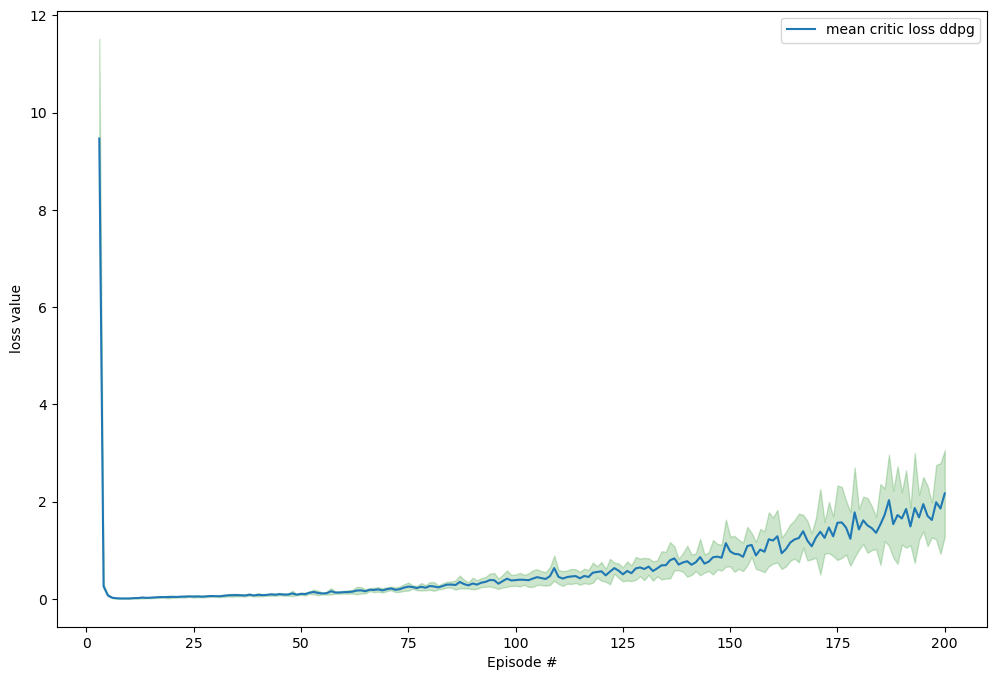

In [50]:
plt.figure(figsize=(12,8))
mean = np.nanmean(ddpg_results['critic_loss'], axis =0)
std = np.nanstd(ddpg_results['critic_loss'], axis =0)
x = np.arange(len(mean))+1
plt.plot(x,mean, label='mean critic loss ddpg')
plt.fill_between(x,mean-std, mean+std, alpha=0.2, color='green')
plt.legend()
plt.xlabel('Episode #')
plt.ylabel('loss value')
plt.show()

## Greedy evaluation

The mean greedy curve reaches -141 by episode 70 and sits at -112 +- 2 from episode 100 onward.
Final greedy return per seed ranges from -110.5 to -117.3.

Per start state, averaged over seeds at the final checkpoint:

    [-3, -123, -130, -125, -124, -119, -251, -127, -133, -3]

Two starts are essentially upright already, one is a hard swing-up, and the rest cost about
-125. The per-episode variance on Pendulum is start-state structure, not policy noise — which is
why the evaluation starts have to be fixed.

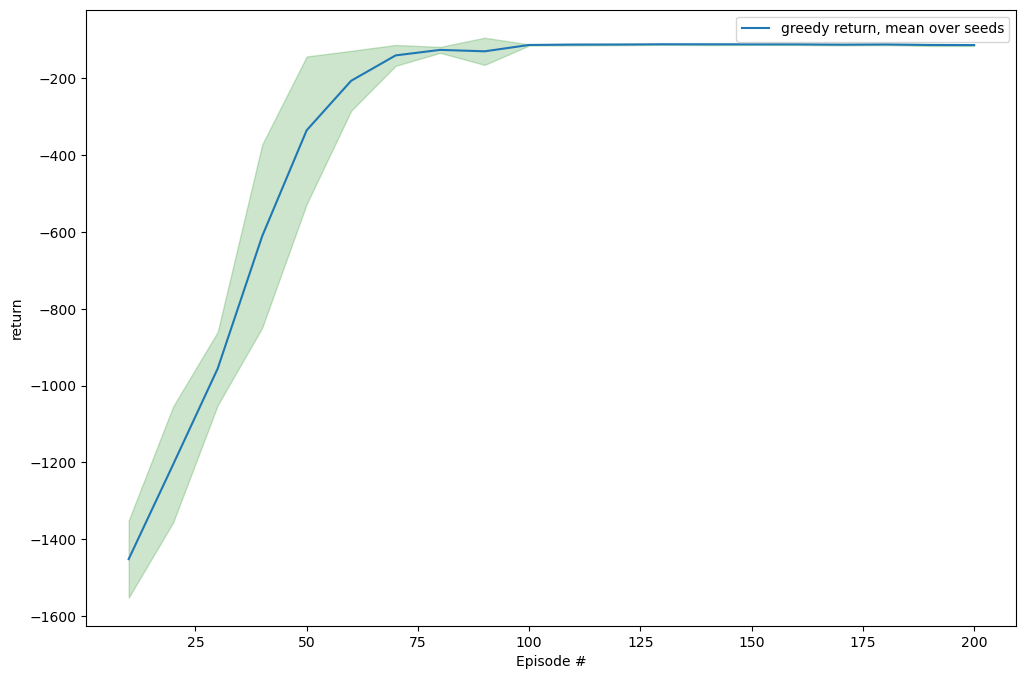

In [52]:
G = ddpg_results['greedy_curve']            # (seeds, checkpoints, eval episodes)
per_seed = G.mean(axis=2)                   # average the 10 eval episodes -> (seeds, checkpoints)
mean = per_seed.mean(axis=0)
std = per_seed.std(axis=0)
x = (np.arange(len(mean)) + 1) * 10         # one checkpoint every 10 episodes

plt.figure(figsize=(12,8))
plt.plot(x, mean, label='greedy return, mean over seeds')
plt.fill_between(x, mean-std, mean+std, alpha=0.2, color='green')
plt.legend()
plt.xlabel('Episode #')
plt.ylabel('return')
plt.show()

## Is there a collapse?

DDPG's reputation is that it reaches a good score and then falls apart. Comparing two fixed
windows of greedy evaluation says it does not here:

- episodes 109-149 -> 159-199: **-0.7 +- 1.0** — flat.
- episodes 59-99 -> 159-199: **+30.6 +- 11.6** — still improving through episode ~100.

Two things about how that was measured are worth more than the number:

**Peak-vs-final manufactures a collapse.** An earlier version compared each seed's *maximum*
20-episode rolling mean against its final 20 episodes, and reported every seed "reaching" about
-124 and "ending" at -176 — a 52-point drop. But the maximum of ~180 overlapping noisy windows sits
above the mean even when nothing changes. Bootstrapping a stationary run from the converged
returns, with zero forgetting by construction, the metric still reports an expected drop of 43.6
(90% range 5-92). The same metric worked for REINFORCE because those drops were 400+ points
against the noise; Pendulum's start-state variance swallows a 50-point effect.

**Fixed evaluation seeds shrank the interval nineteenfold.** The same window comparison on the
earlier version, with random eval starts, gave -1.8 +- 19.2. Same algorithm, same ten seeds; only
the pairing changed.

In [53]:
G = ddpg_results["greedy_curve"]              # (10 seeds, 20 checkpoints, 10 eval episodes)
mid  = G[:, 10:15].mean(axis=(1, 2))          # checkpoints at episodes 109-149
late = G[:, 15:20].mean(axis=(1, 2))          # checkpoints at episodes 159-199
d = late - mid
print(f"change, episodes 109-149 -> 159-199: {d.mean():+.1f} ± {1.96*d.std(ddof=1)/np.sqrt(len(d)):.1f} (95% CI)")

change, episodes 109-149 -> 159-199: -0.7 ± 1.0 (95% CI)


In [56]:
start_mid  = G[:, 5:10].mean(axis=(1, 2))          # checkpoints at episodes 59-99
d = late - start_mid
print(f"change, episodes 59-99 -> 159-199: {d.mean():+.1f} ± {1.96*d.std(ddof=1)/np.sqrt(len(d)):.1f} (95% CI)")

change, episodes 59-109 -> 159-199: +30.6 ± 11.6 (95% CI)


## What this means for TD3

Nothing here for it to fix. DDPG converges tightly on all ten seeds, does not collapse, and its
critic stays inside the hard ceiling. A TD3 comparison on Pendulum would most likely be a null
result — fine if framed that way, but it would not show what TD3 is for. The TD3 paper's case is
made on MuJoCo tasks (HalfCheetah, Hopper, Walker) where DDPG's critic overestimates and its
performance degrades; that is where the comparison belongs.

In [54]:
np.savez(
    "ddpg_pendulum.npz",
    scores=ddpg_results["scores"],
    q_values=ddpg_results["q_values"],
    actor_loss=ddpg_results['actor_loss'],
    critic_loss=ddpg_results["critic_loss"],
    greedy_evals=ddpg_results['greedy_evals'],
    greedy_curve=ddpg_results['greedy_curve']
)